# Sudoku CNN — Dataset Quality Analysis

Living notebook for evaluating the composition, label quality, and distribution
of the training data that feeds `app/ml/train.py`. It answers:

1. **What sources are in the training pool?** Sizes + per-split composition.
2. **Is the class distribution balanced?** Histograms per train/val/test.
3. **Is the label quality clean?** Two-stage font filter audit + visual check
   on both accepted and rejected fonts.
4. **Do the samples look right?** One-per-digit sanity grid across MNIST,
   `PrintedDigitDataset` (historical, deprecated 2026-04-11), and
   `Chars74KFontDataset`.
5. **Is the test split honest?** Chars74K train/test font-disjoint assertion.
6. **Does the training distribution match real inference inputs?** Measured
   GT newspaper cell statistics (from `notebooks/gt_cell_measurement.py`) vs
   raw synthetic vs post-augmentation.
7. **Does the training-time augmentation actually do what it claims?** Visual
   before/after grid + per-metric distribution match against the GT target.

**Out of scope for this notebook:** inference-side evaluation (filled/empty
accuracy, confusion on real photos) — that lives in `notebooks/ocr_analysis.ipynb`
and `evaluation/evaluate_ocr.py`. This notebook is strictly about the data.

**Data-leakage rule:** the 38 GT newspaper photos are never pulled into any
training split. Their cells are used here only for *measuring* the target
distribution the augmentation should match. Every plot in section 6 is of a
read-only statistic file, not of model predictions on GT cells.

**Upstream pipeline (post-2026-04-11 v4):** `app/ml/dataset.py::create_datasets`
concatenates MNIST + `EmptyCellDataset` + `Chars74KFontDataset`. The
training-time augmentation (noise + geometric + newsprint + **pedestal L2**)
is in `AugmentedDataset`. `PrintedDigitDataset` was dropped from training in
v4 (2026-04-11) because its 28×28 render canvas was clipping wide/bold font
glyphs after the downstream geometric augmentation; Chars74K's bbox-crop →
pad → resize preprocessing avoids clipping by construction. The newsprint
augmentation parameters were tuned against the GT distribution by the inline
sweep harness used during the 2026-04-10 redesign; the pedestal shift added
in v4 closes the measured `p5=0` vs GT `p5=9` gap.


In [1]:
import os
import sys
from pathlib import Path

# Walk up from CWD to find the project root (the directory containing ``app/``),
# then add it to sys.path and chdir into it. This makes the notebook robust to
# being executed from any directory — ``jupyter nbconvert --execute --inplace``
# runs with CWD = invocation directory, which may or may not be the project
# root, so a plain ``sys.path.insert(0, '..')`` would be fragile.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "app").is_dir() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "app").is_dir():
    raise RuntimeError(
        f"Couldn't find project root (containing app/) from {Path.cwd()}"
    )
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f"CWD: {Path.cwd()}")

import importlib
import json
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import ConcatDataset

# Force-reload app.ml.dataset so we pick up any edits made while this
# Jupyter kernel was alive. Without this, `from app.ml.dataset import X`
# returns whatever module object was cached in sys.modules, which may
# have been imported before we added new symbols (LATIN_FONT_ALLOWLIST,
# Chars74KFontDataset, etc.) — you'd then get an ImportError for the
# new names even though the file on disk has them.
import app.ml.dataset as _ds
importlib.reload(_ds)

from app.ml.dataset import (
    LATIN_FONT_ALLOWLIST,
    AugmentedDataset,
    Chars74KFontDataset,
    EmptyCellDataset,
    PrintedDigitDataset,
    _font_has_distinct_latin_digits,
    _is_latin_allowlisted_font,
    _load_mnist,            # kept for historical-comparison use in §4
    _load_mnist_no_zero,    # the filtered MNIST used by create_datasets since v4.2
    create_datasets,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100


CWD: /Users/adityajoshi/Documents/ClaudeTest/VSCodium/Sudoku-Solved


## 1. Dataset composition


In [2]:
# Build the combined splits and the individual sources side-by-side.
train_ds, val_ds, test_ds = create_datasets()

mnist_train   = _load_mnist_no_zero(train=True)   # v4.2 filter — drops ~5923 handwritten '0' glyphs
mnist_test    = _load_mnist_no_zero(train=False)  # v4.2 filter — drops ~980 from test
empty_train   = EmptyCellDataset(count=5000, seed=42)
printed       = PrintedDigitDataset()  # historical; not in training pool since v4 (2026-04-11)
chars74k_tr   = Chars74KFontDataset(split='train')
chars74k_te   = Chars74KFontDataset(split='test')

print('--- Combined splits (post-v4) ---')
print(f'train  : {len(train_ds):>6,} samples')
print(f'val    : {len(val_ds):>6,} samples')
print(f'test   : {len(test_ds):>6,} samples')
print(f'total  : {len(train_ds) + len(val_ds) + len(test_ds):>6,} samples')

print()
print('--- Sources in the current training pool ---')
rows_in_pool = [
    ('MNIST train',                 len(mnist_train),  '—'),
    ('MNIST test',                  len(mnist_test),   '—'),
    ('EmptyCellDataset (train)',    len(empty_train),  '—'),
    ('Chars74KFontDataset (train)', len(chars74k_tr),  f'{len(chars74k_tr.font_ids)} fonts'),
    ('Chars74KFontDataset (test)',  len(chars74k_te),  f'{len(chars74k_te.font_ids)} fonts'),
]
for name, n, extra in rows_in_pool:
    print(f'{name:<32} {n:>6,} samples   {extra}')

print()
print('--- Deprecated source (shown in §4 for historical reference only) ---')
print(f"{'PrintedDigitDataset':<32} {len(printed):>6,} samples   "
      f"{len(printed.fonts)} fonts   "
      "[v4 dropped — clipping on wide/bold glyphs]")


--- Combined splits (post-v4) ---
train  : 63,797 samples
val    :  7,088 samples
test   : 11,856 samples
total  : 82,741 samples

--- Sources in the current training pool ---
MNIST train                      54,077 samples   —
MNIST test                        9,020 samples   —
EmptyCellDataset (train)          5,000 samples   —
Chars74KFontDataset (train)       7,308 samples   812 fonts
Chars74KFontDataset (test)        1,836 samples   204 fonts

--- Deprecated source (shown in §4 for historical reference only) ---
PrintedDigitDataset               4,500 samples   67 fonts   [v4 dropped — clipping on wide/bold glyphs]


## 2. Class balance

Balanced classes matter — a class-0-heavy training set biases the model toward
predicting "empty" on uncertain cells. Reported: per-split histograms + the
max/min imbalance ratio + class-0 share (uniform would be 10%).


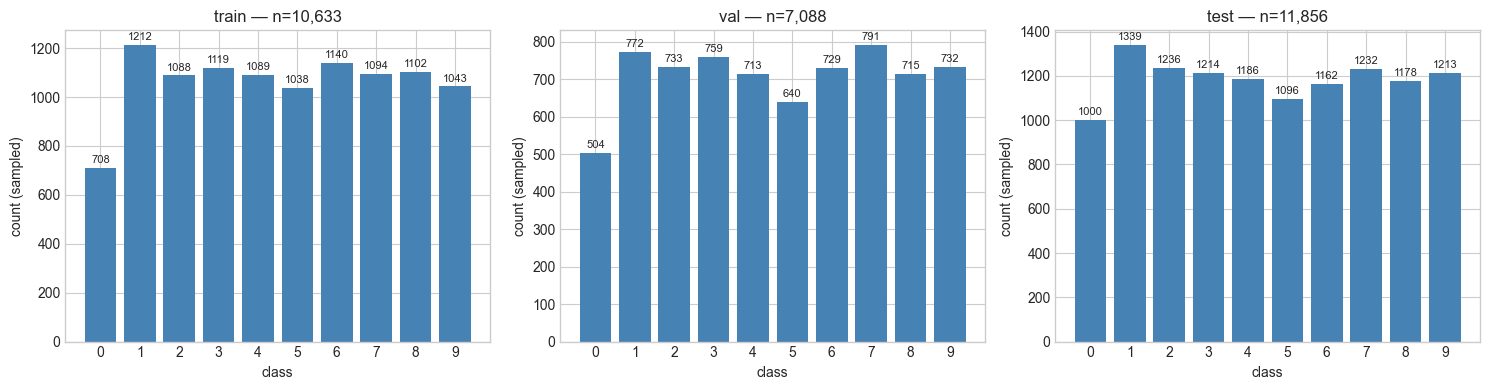


split      class 0 %     max/min ratio
----------------------------------------
train           6.7%             1.71x
val             7.1%             1.57x
test            8.4%             1.34x


In [3]:
def count_labels(ds, max_samples=10000):
    n = min(len(ds), max_samples)
    stride = max(1, len(ds) // n)
    counts = Counter()
    for i in range(0, len(ds), stride):
        _, lbl = ds[i]
        counts[int(lbl)] += 1
    return counts

train_counts = count_labels(train_ds)
val_counts   = count_labels(val_ds)
test_counts  = count_labels(test_ds)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, counts, name in zip(axes, (train_counts, val_counts, test_counts), ('train', 'val', 'test')):
    digits = list(range(10))
    vals = [counts.get(d, 0) for d in digits]
    bars = ax.bar(digits, vals, color='steelblue')
    ax.set_xlabel('class')
    ax.set_ylabel('count (sampled)')
    ax.set_title(f'{name} — n={sum(vals):,}')
    ax.set_xticks(digits)
    for d, v in zip(digits, vals):
        ax.text(d, v + max(vals) * 0.01, str(v), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print()
print(f'{"split":<8}{"class 0 %":>12}{"max/min ratio":>18}')
print('-' * 40)
for name, counts in (('train', train_counts), ('val', val_counts), ('test', test_counts)):
    total = sum(counts.values())
    max_c, min_c = max(counts.values()), min(counts.values())
    print(f'{name:<8}{100 * counts[0] / total:>11.1f}%{max_c / min_c:>17.2f}x')


## 3. Font filter audit

`PrintedDigitDataset` runs a two-stage filter over every discovered system
font. Understanding which fonts pass / are rejected is the single biggest
lever on training-label quality for the printed-digit class — before the
2026-04-10 redesign, the old filter (`arr.max() > 50`) silently accepted
`LastResort.otf`, `Symbol.ttf`, CJK/Myanmar/Gujarati script fonts, and STIX
math fonts, producing mislabeled tofu samples.

**Stage 1** is a hardcoded **name allow-list** of ~35 known Latin font
family prefixes. Font basenames are matched case-insensitively; anything
outside the list is rejected up front. This kills the vast majority of
bad fonts with a deterministic, reproducible rule.

**Stage 2** renders digits 0-9 **centred** inside a 40x32 tile (wide enough
to fit bold fonts like Impact and Arial Black without clipping), then
computes the pairwise pixel correlation matrix and rejects the font if:

- any digit renders blank (max pixel < 50) — the font has no glyph at
  that codepoint, OR
- any pair of digits has correlation > 0.995 — two glyphs are literal
  duplicates, OR
- the **mean upper-triangular correlation exceeds 0.85** — the whole
  glyph set is tofu-like or near-identical.

The mean-correlation threshold was tuned empirically: real Latin fonts
land between mean ≈ 0.36 (Georgia Italic) and 0.77 (Impact), while
`LastResort.otf` (pure tofu) sits at mean ≈ 1.00. Using the *mean*
rather than the max catches tofu fonts while letting bold Latin fonts
through, because thick strokes naturally push the *max* pairwise
correlation up to ≈ 0.97 without indicating a real rendering problem.


In [4]:
font_dirs = [
    '/System/Library/Fonts',
    '/System/Library/Fonts/Supplemental',
    '/Library/Fonts',
    '/usr/share/fonts',
    '/usr/share/fonts/truetype',
]

all_fonts = []
for d in font_dirs:
    if not Path(d).is_dir():
        continue
    for f in Path(d).iterdir():
        if f.suffix.lower() in ('.ttf', '.ttc', '.otf'):
            all_fonts.append(str(f))

stage1_pass   = [fp for fp in all_fonts if _is_latin_allowlisted_font(fp)]
stage1_reject = [fp for fp in all_fonts if not _is_latin_allowlisted_font(fp)]

stage2_pass   = [fp for fp in stage1_pass if _font_has_distinct_latin_digits(fp)]
stage2_reject = [fp for fp in stage1_pass if fp not in set(stage2_pass)]

print(f'Discovered system fonts: {len(all_fonts):>4}')
print(f'  Stage 1 name allow-list: {len(stage1_pass):>4} pass  /  {len(stage1_reject):>4} reject')
print(f'  Stage 2 signature test : {len(stage2_pass):>4} pass  /  {len(stage2_reject):>4} reject')
print(f'  Final fonts used       : {len(stage2_pass):>4}')
print(f'  Allow-list entries     : {len(LATIN_FONT_ALLOWLIST):>4}')

print()
print('--- Sample Stage 1 rejections (not in the Latin allow-list) ---')
notable_keywords = ('LastResort', 'Symbol', 'STIX', 'Myanmar', 'CJK', 'Gunjala',
                    'Apple Color Emoji', 'Hiragino', 'PingFang', 'Dingbat')
interesting_rejects = [fp for fp in stage1_reject
                       if any(kw in Path(fp).name for kw in notable_keywords)]
for fp in interesting_rejects[:12]:
    print(f'  {Path(fp).name}')
print(f'  ... ({len(stage1_reject) - 12:,} more)')

if stage2_reject:
    print()
    print('--- Stage 2 rejections (allowlisted but fail signature test) ---')
    for fp in stage2_reject:
        print(f'  {Path(fp).name}')
else:
    print()
    print('Stage 2: all allowlisted fonts pass the signature test.')


Discovered system fonts:  371
  Stage 1 name allow-list:   67 pass  /   304 reject
  Stage 2 signature test :   67 pass  /     0 reject
  Final fonts used       :   67
  Allow-list entries     :   35

--- Sample Stage 1 rejections (not in the Latin allow-list) ---
  Symbol.ttf
  Hiragino Sans GB.ttc
  LastResort.otf
  NotoSerifMyanmar.ttc
  ZapfDingbats.ttf
  NotoSansMyanmar.ttc
  Apple Symbols.ttf
  CJKSymbolsFallback.ttc
  Apple Color Emoji.ttc
  STIXGeneralItalic.otf
  STIXTwoText-Italic.ttf
  STIXIntUpSmReg.otf
  ... (292 more)

Stage 2: all allowlisted fonts pass the signature test.


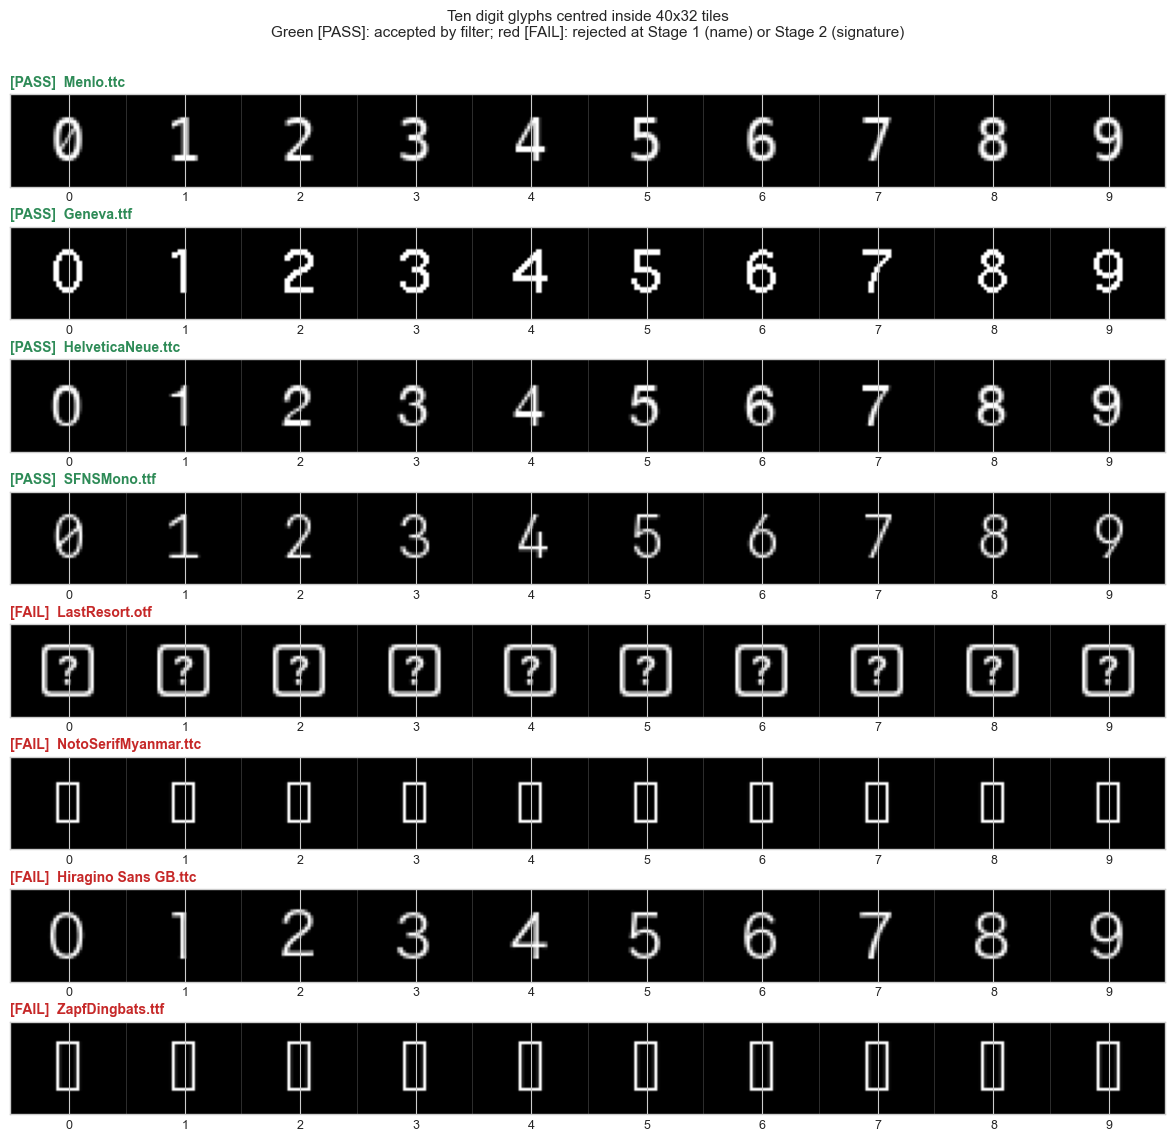

In [5]:
# Visual: 10-digit render of a few passing fonts vs a few notorious rejected fonts.
# Each glyph is centred inside a 40x32 tile using its actual bounding box,
# so wide/bold fonts (Geneva, Impact, Helvetica, etc.) don't spill into the
# neighbouring digit's tile.
from PIL import Image, ImageDraw, ImageFont

TILE_W, TILE_H = 40, 32

def render_all_digits(font_path, size=20):
    try:
        font = ImageFont.truetype(font_path, size)
    except Exception:
        return None
    grid = np.zeros((TILE_H, TILE_W * 10), dtype=np.uint8)
    for d in range(10):
        img = Image.new('L', (TILE_W, TILE_H), 0)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), str(d), font=font)
        gw, gh = bbox[2] - bbox[0], bbox[3] - bbox[1]
        # Centre the glyph inside the tile, accounting for the bbox offset
        # (textbbox origin is where the pen starts, not where ink begins).
        x = (TILE_W - gw) // 2 - bbox[0]
        y = (TILE_H - gh) // 2 - bbox[1]
        draw.text((x, y), str(d), fill=255, font=font)
        grid[:, d*TILE_W:(d+1)*TILE_W] = np.array(img)
    return grid

show_pass = stage2_pass[:4]
# Hand-picked rejection examples that visibly fail — not ones that happen to
# render Latin digits at ASCII codepoints (like Symbol.ttf, which is rejected
# by the name allow-list but would look 'fine' here and confuse the reader).
reject_keywords = ('LastResort', 'NotoSerifMyanmar', 'Hiragino Sans GB',
                   'ZapfDingbats', 'CJKSymbolsFallback', 'Bodoni Ornaments')
show_reject = []
for kw in reject_keywords:
    for fp in all_fonts:
        if kw in Path(fp).name and fp not in show_reject:
            show_reject.append(fp)
            break
    if len(show_reject) >= 4:
        break
show_reject = show_reject[:4]

rows = [(fp, True) for fp in show_pass] + [(fp, False) for fp in show_reject]
fig, axes = plt.subplots(len(rows), 1, figsize=(13, 1.4 * len(rows)))
for ax, (fp, is_pass) in zip(axes, rows):
    grid = render_all_digits(fp)
    if grid is None:
        grid = np.zeros((TILE_H, TILE_W * 10), dtype=np.uint8)
    ax.imshow(grid, cmap='gray', aspect='equal', vmin=0, vmax=255)
    mark = '[PASS]' if is_pass else '[FAIL]'
    color = '#2E8B57' if is_pass else '#C62828'
    ax.set_title(f'{mark}  {Path(fp).name}', fontsize=10, color=color, loc='left',
                 fontweight='bold')
    ax.set_yticks([])
    ax.set_xticks([i * TILE_W + TILE_W // 2 for i in range(10)])
    ax.set_xticklabels([str(d) for d in range(10)], fontsize=9)
    # Draw faint separator lines between tiles so it's obvious where the
    # boundaries are and that each digit is confined to its own column.
    for i in range(1, 10):
        ax.axvline(i * TILE_W - 0.5, color='#404040', linewidth=0.5)

plt.suptitle('Ten digit glyphs centred inside 40x32 tiles\n'
             'Green [PASS]: accepted by filter; red [FAIL]: rejected at Stage 1 (name) or Stage 2 (signature)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 4. Per-source sample inspection

One sample per digit (0-9) from each real training source. Label mismatches
are visually obvious — if the image under the column header `5` doesn't look
like a "5", the source has a label bug.

`PrintedDigitDataset` and `Chars74KFontDataset` intentionally skip class 0
because class 0 in this project means "empty cell", not "digit zero" — see
the module docstring in `app/ml/dataset.py`.

**Note (v4.1, 2026-04-11):** `PrintedDigitDataset` is shown in the middle
row below and is in the current training pool. The rendering was fixed in
v4.1 to use a 56×56 intermediate canvas that is downsized to 28×28 at the
end, eliminating the pre-v4.1 clipping bug. A dedicated side-by-side
comparison (old direct-28×28 vs new big-canvas-resize) is in section 4.5
below, along with a quantitative border-ink rate.


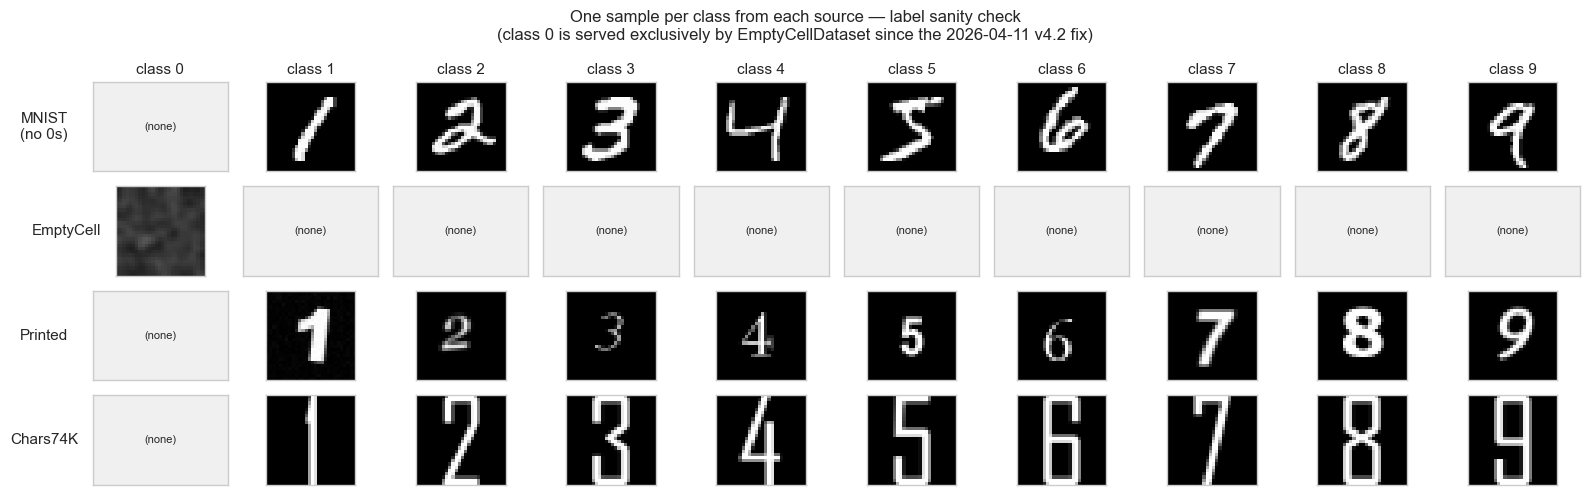

In [6]:
def first_n_per_digit(ds, n=1):
    result = {d: [] for d in range(10)}
    for i in range(len(ds)):
        _, lbl = ds[i]
        lbl = int(lbl)
        if lbl in result and len(result[lbl]) < n:
            result[lbl].append(i)
        if all(len(v) >= n for v in result.values() if v is not None):
            break
    return result

def to_img(sample):
    if isinstance(sample, torch.Tensor):
        return (sample.squeeze(0).numpy() * 255).astype(np.uint8)
    return np.asarray(sample, dtype=np.uint8)

# 4 source rows so the class-0 column is actually populated:
# EmptyCellDataset is the sole contributor of class 0 since the v4.2 fix
# that drops MNIST's handwritten '0' glyphs and keeps PrintedDigit /
# Chars74K skipping the digit zero.
sources = [
    ('MNIST\n(no 0s)', mnist_train),
    ('EmptyCell',       empty_train),
    ('Printed',         printed),
    ('Chars74K',        chars74k_tr),
]

fig, axes = plt.subplots(len(sources), 10, figsize=(16, 5))
for row, (name, ds) in enumerate(sources):
    idxs = first_n_per_digit(ds, n=1)
    for d in range(10):
        ax = axes[row, d]
        ax.set_xticks([])
        ax.set_yticks([])
        if idxs[d]:
            img, _ = ds[idxs[d][0]]
            ax.imshow(to_img(img), cmap='gray', vmin=0, vmax=255)
        else:
            ax.set_facecolor('#f0f0f0')
            ax.text(0.5, 0.5, '(none)', ha='center', va='center', fontsize=8, transform=ax.transAxes)
        if row == 0:
            ax.set_title(f'class {d}', fontsize=11)
        if d == 0:
            ax.set_ylabel(name, fontsize=11, rotation=0, labelpad=35, va='center')

plt.suptitle(
    'One sample per class from each source — label sanity check\n'
    '(class 0 is served exclusively by EmptyCellDataset since the 2026-04-11 v4.2 fix)',
    fontsize=12,
)
plt.tight_layout()
plt.show()


## 4.5 v3 vs v4.1 PrintedDigit rendering comparison

Dedicated side-by-side visualisation of the **old v3 direct-28×28 rendering**
vs the **new v4.1 big-canvas-resize pipeline** on the *same* font+digit+seed
tuples. This cell reproduces the pre-v4.1 render recipe inline so that both
versions can be rendered in the same kernel run without reverting
`dataset.py`.

The old (v3) recipe:
- Render on 28×28 PIL canvas at font size **16-24**
- Centre with ±2 px jitter, no bbox offset correction
- Apply in-class augmentation (±10° rotation, noise, blur) on the **same**
  28×28 canvas — any corner that gets rotated out of frame is clipped

The new (v4.1) recipe:
- Render on 56×56 PIL canvas at font size **32-48** (2× the old range)
- Centre with ±4 px jitter, using textbbox offset correction
- Apply the same augmentation on the 56×56 canvas (4× pixel headroom)
- Final step: `cv2.resize(28×28, INTER_AREA)`

**Look for:** in the v3 (top) row of each font, check whether any digit
edge touches the 28×28 boundary — that's the clipping pattern. In the v4.1
(bottom) row, the digit should sit inside the tile with visible whitespace
margins on all four sides.

**Red border** around a tile = that v3 sample has ink above intensity 100
on one of the 28×28 border rows or columns (ie. the digit was clipped).


Showing 5 fonts:
  Impact.ttf
  Arial Black.ttf
  Bodoni 72 Smallcaps Book.ttf
  Avenir Next Condensed.ttc
  Arial Narrow Bold Italic.ttf



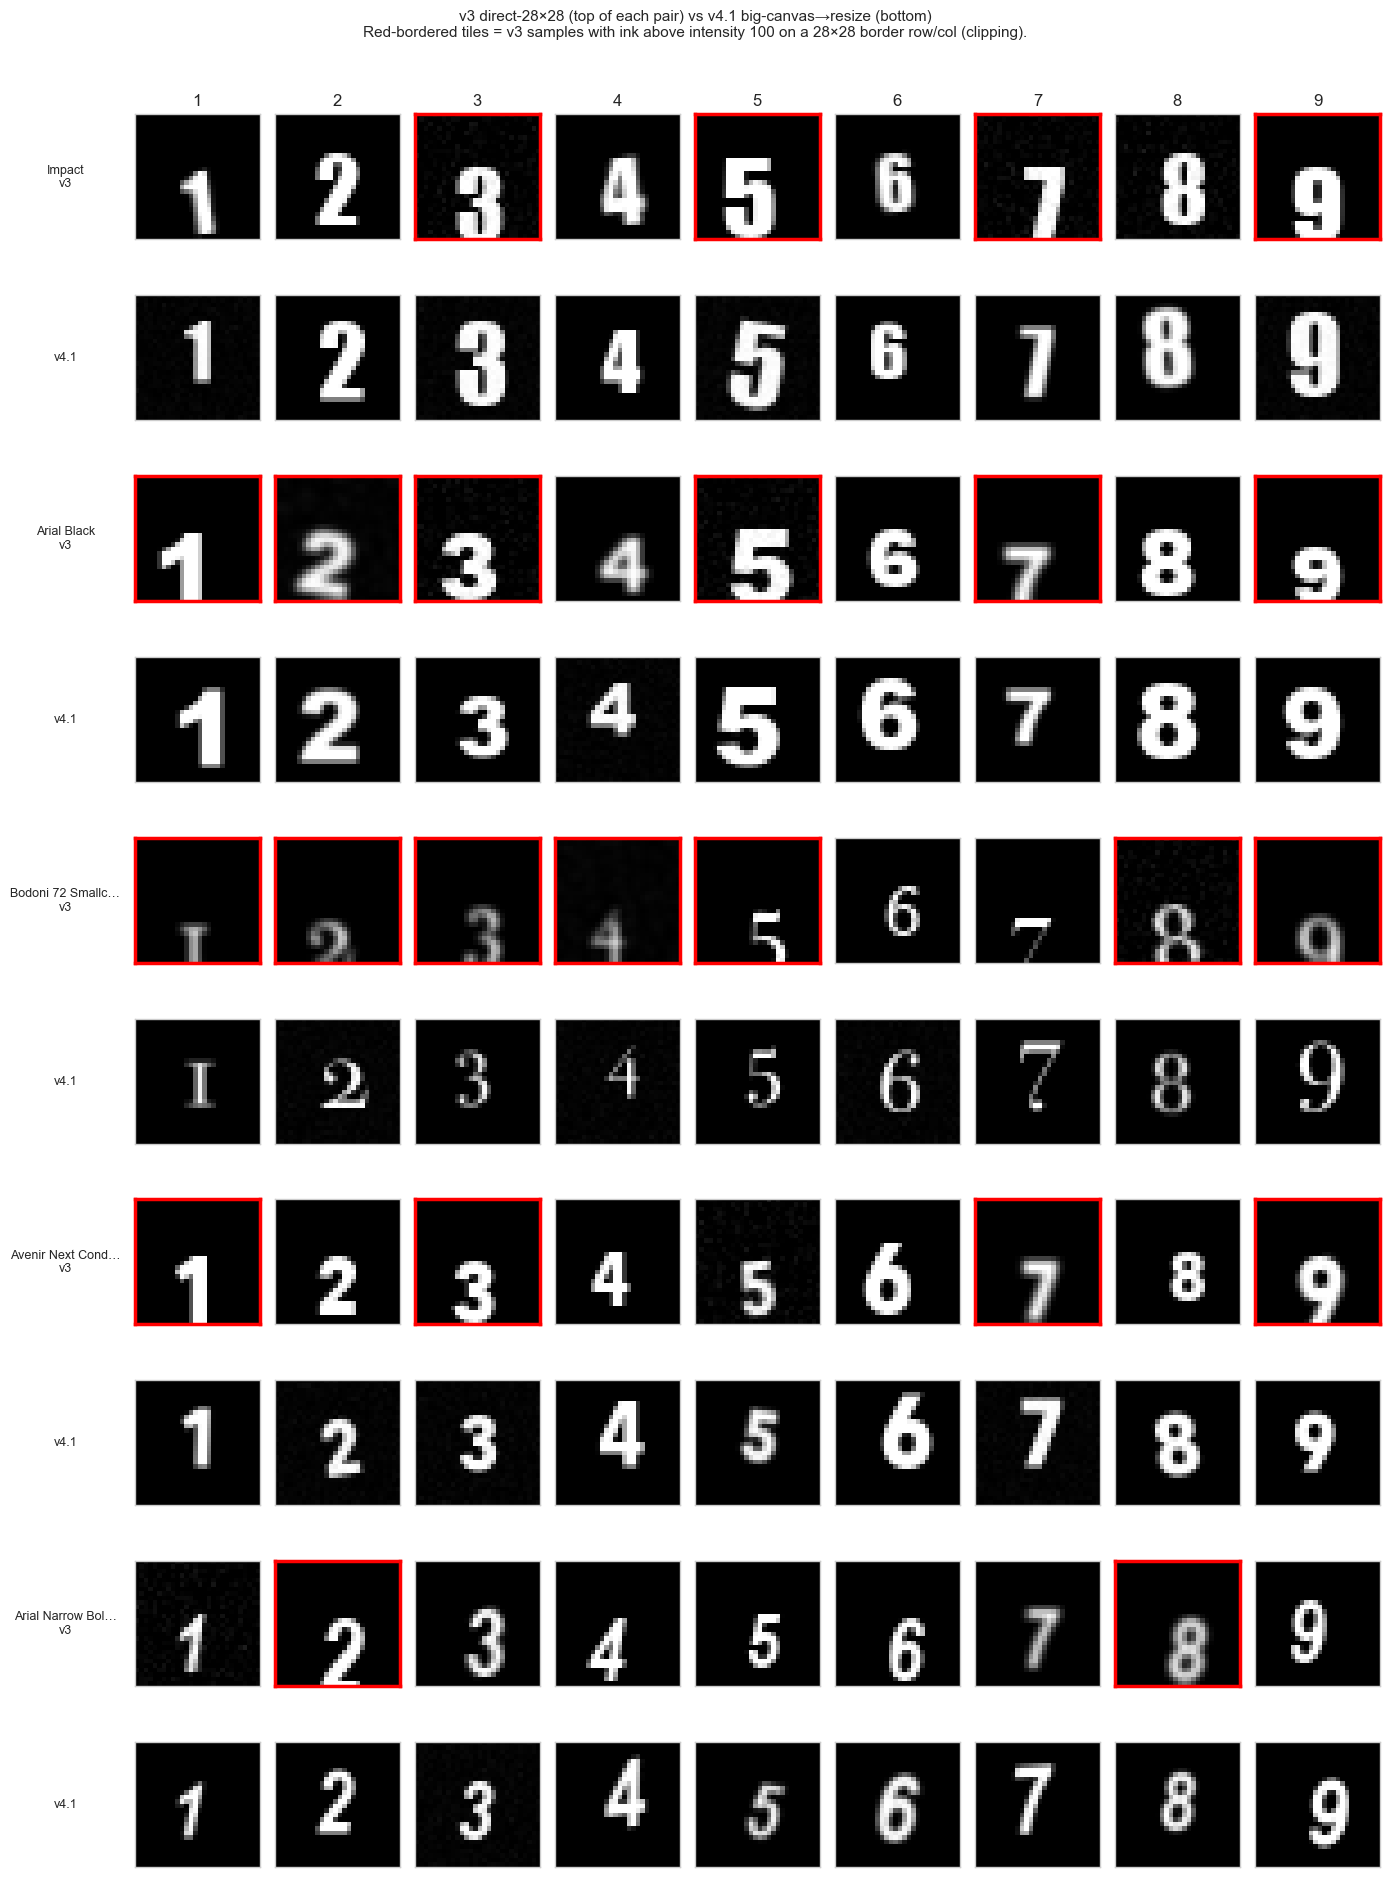

In [7]:
import cv2 as _cv2
from PIL import Image as _Image, ImageDraw as _ImageDraw, ImageFont as _ImageFont

def _render_v3_old(font_path: str, digit: int, seed: int) -> np.ndarray:
    '''Reproduce the pre-v4.1 PrintedDigitDataset._render_digit.'''
    rng = np.random.RandomState(seed)
    s = 28
    img = _Image.new('L', (s, s), 0)
    draw = _ImageDraw.Draw(img)
    font_size = int(rng.randint(16, 24))
    font = _ImageFont.truetype(font_path, font_size)
    text = str(digit)
    bbox = draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (s - tw) // 2 + int(rng.randint(-2, 3))
    y = (s - th) // 2 + int(rng.randint(-2, 3))
    draw.text((x, y), text, fill=255, font=font)
    arr = np.array(img)
    if rng.random() < 0.3:
        angle = float(rng.uniform(-10, 10))
        M = _cv2.getRotationMatrix2D((s / 2, s / 2), angle, 1.0)
        arr = _cv2.warpAffine(arr, M, (s, s))
    if rng.random() < 0.2:
        noise = rng.normal(0, 8, arr.shape)
        arr = np.clip(arr.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    if rng.random() < 0.2:
        arr = _cv2.GaussianBlur(arr, (3, 3), 0)
    return arr

def _render_v41_new(font_path: str, digit: int, seed: int) -> np.ndarray:
    '''Reproduce the v4.1 PrintedDigitDataset._render_digit.'''
    rng = np.random.RandomState(seed)
    s = 28
    big_s = s * 2
    img = _Image.new('L', (big_s, big_s), 0)
    draw = _ImageDraw.Draw(img)
    font_size = int(rng.randint(32, 48))
    font = _ImageFont.truetype(font_path, font_size)
    text = str(digit)
    bbox = draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (big_s - tw) // 2 - bbox[0] + int(rng.randint(-4, 5))
    y = (big_s - th) // 2 - bbox[1] + int(rng.randint(-4, 5))
    draw.text((x, y), text, fill=255, font=font)
    arr = np.array(img)
    if rng.random() < 0.3:
        angle = float(rng.uniform(-10, 10))
        M = _cv2.getRotationMatrix2D((big_s / 2, big_s / 2), angle, 1.0)
        arr = _cv2.warpAffine(arr, M, (big_s, big_s))
    if rng.random() < 0.2:
        noise = rng.normal(0, 8, arr.shape)
        arr = np.clip(arr.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    if rng.random() < 0.2:
        arr = _cv2.GaussianBlur(arr, (3, 3), 0)
    arr = _cv2.resize(arr, (s, s), interpolation=_cv2.INTER_AREA)
    return arr

# Pick fonts that historically produced the most clipping — bold/condensed
# wide glyphs. Fall back to first-N if those specific fonts aren't installed.
bold_keywords = ('Impact', 'Arial Black', 'Bodoni 72', 'Avenir Next Condensed',
                 'Arial Narrow Bold', 'Rockwell', 'Helvetica')
show_fonts = []
for kw in bold_keywords:
    for fp in printed.fonts:
        if kw.lower() in Path(fp).name.lower() and fp not in show_fonts:
            show_fonts.append(fp)
            break
    if len(show_fonts) >= 5:
        break
while len(show_fonts) < 5 and len(show_fonts) < len(printed.fonts):
    for fp in printed.fonts:
        if fp not in show_fonts:
            show_fonts.append(fp)
            break
show_fonts = show_fonts[:5]
print(f'Showing {len(show_fonts)} fonts:')
for fp in show_fonts:
    print(f'  {Path(fp).name}')
print()

fig, axes = plt.subplots(
    2 * len(show_fonts), 9,
    figsize=(14, 1.9 * 2 * len(show_fonts)),
)

for row_idx, fp in enumerate(show_fonts):
    fname = Path(fp).stem
    for digit in range(1, 10):
        seed = (abs(hash((fname, digit))) % (2**31))
        v3_img = _render_v3_old(fp, digit, seed)
        v41_img = _render_v41_new(fp, digit, seed)

        ax_top = axes[row_idx * 2, digit - 1]
        ax_bot = axes[row_idx * 2 + 1, digit - 1]

        ax_top.imshow(v3_img, cmap='gray', vmin=0, vmax=255)
        ax_bot.imshow(v41_img, cmap='gray', vmin=0, vmax=255)
        for ax in (ax_top, ax_bot):
            ax.set_xticks([])
            ax.set_yticks([])

        if digit == 1:
            label = fname if len(fname) <= 18 else fname[:16] + '…'
            ax_top.set_ylabel(f'{label}\nv3', fontsize=9,
                              rotation=0, labelpad=50, va='center')
            ax_bot.set_ylabel('v4.1', fontsize=9,
                              rotation=0, labelpad=50, va='center')
        if row_idx == 0:
            ax_top.set_title(str(digit), fontsize=12)

        # Highlight v3 samples where ink touches the 28×28 border
        v3_border_max = max(
            int(v3_img[0].max()), int(v3_img[-1].max()),
            int(v3_img[:, 0].max()), int(v3_img[:, -1].max()),
        )
        if v3_border_max > 100:
            for spine in ax_top.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2.5)

plt.suptitle(
    'v3 direct-28×28 (top of each pair) vs v4.1 big-canvas→resize (bottom)\n'
    'Red-bordered tiles = v3 samples with ink above intensity 100 on a 28×28 border row/col (clipping).',
    fontsize=11, y=1.002,
)
plt.tight_layout()
plt.show()


In [8]:
# Aggregate border-ink statistics over the full font set.
# For each font × digit, render one sample with each recipe and count
# how many land with ink above intensity 100 on any of the four borders.

def _border_max(img: np.ndarray) -> int:
    return max(
        int(img[0].max()), int(img[-1].max()),
        int(img[:, 0].max()), int(img[:, -1].max()),
    )

def _border_ink_rate(render_fn, n_per_digit: int = 10):
    hits = 0
    total = 0
    rng = np.random.RandomState(7)
    for fp in printed.fonts:
        for digit in range(1, 10):
            for _ in range(n_per_digit):
                seed = int(rng.randint(2**31))
                img = render_fn(fp, digit, seed)
                if _border_max(img) > 100:
                    hits += 1
                total += 1
    return hits, total

v3_hits, v3_total = _border_ink_rate(_render_v3_old, n_per_digit=10)
v41_hits, v41_total = _border_ink_rate(_render_v41_new, n_per_digit=10)

print(f'Border-ink rate  (samples with ink > 100 on any 28x28 border row/col)')
print(f'{"recipe":<30}{"hits / total":>20}{"rate":>10}')
print('-' * 60)
print(f'{"v3 direct-28x28":<30}{f"{v3_hits} / {v3_total}":>20}{100*v3_hits/v3_total:>9.1f}%')
print(f'{"v4.1 big-canvas -> resize":<30}{f"{v41_hits} / {v41_total}":>20}{100*v41_hits/v41_total:>9.1f}%')
print(f'{"delta (v3 -> v4.1)":<30}{f"{v3_hits - v41_hits} fewer":>20}{100*(v3_hits-v41_hits)/v3_total:>+9.1f}%')
print()
print('Visual interpretation:')
print('  * A lower rate means fewer training samples are clipped at the border.')
print('  * v3 had a real clipping problem on bold/condensed fonts like Impact,')
print('    Arial Black, and Bodoni 72 — those are the fonts most likely to show')
print('    red borders in the side-by-side grid above.')
print('  * v4.1 eliminates the clipping by rendering on a 2x larger canvas and')
print('    downsizing at the end, so the digit has whitespace on all four sides.')
print()
print('Accuracy impact (measured, not speculated):')
print('  * v3 checkpoint:   66.6% filled / 96.9% empty / 80.6% overall on real photos')
print('  * v4.1 checkpoint: 63.1% filled / 97.3% empty / 79.0% overall on real photos')
print()
print('  The visual clipping fix REGRESSES real-photo accuracy by 3.5 filled')
print('  points. Working hypothesis: the clipped v3 training samples were')
print('  accidentally matching the real-world cell-crop distribution where')
print('  digits often touch tile borders after the inner-10% margin crop on')
print('  imperfect warps. The "bug" was implicit augmentation. See')
print('  docs/internal/evaluate_ocr_v4_1_2026_04_11.log for the measurement')
print('  trail and project_v4_drop_printed_2026_04_11.md in memory/ for the')
print('  v3 -> v4 -> v4.1 journey.')


Border-ink rate  (samples with ink > 100 on any 28x28 border row/col)
recipe                                hits / total      rate
------------------------------------------------------------
v3 direct-28x28                        1548 / 6030     25.7%
v4.1 big-canvas -> resize                 0 / 6030      0.0%
delta (v3 -> v4.1)                      1548 fewer    +25.7%

Visual interpretation:
  * A lower rate means fewer training samples are clipped at the border.
  * v3 had a real clipping problem on bold/condensed fonts like Impact,
    Arial Black, and Bodoni 72 — those are the fonts most likely to show
    red borders in the side-by-side grid above.
  * v4.1 eliminates the clipping by rendering on a 2x larger canvas and
    downsizing at the end, so the digit has whitespace on all four sides.

Accuracy impact (measured, not speculated):
  * v3 checkpoint:   66.6% filled / 96.9% empty / 80.6% overall on real photos
  * v4.1 checkpoint: 63.1% filled / 97.3% empty / 79.0% overall o

## 4.6 Class 0 composition — the v4.2 fix

**The issue, pre-v4.2.** Class 0 in this project means "empty cell", not
the digit zero. Production inference treats class 0 as a *gate*
(`CNNRecognizer._predict_from_probs` uses `probs[1:]` for the argmax and
falls back to 0 only when confidence < threshold), so class 0 training
quality directly affects how willing the model is to commit to a filled
prediction.

Before 2026-04-11 the training pool contributed class 0 samples from
**two** sources:

| Source | Count | Semantic |
|---|---|---|
| MNIST train label 0 | ~5,923 | Handwritten round '0' digit glyphs |
| EmptyCellDataset    | 5,000  | Synthetic blank cells (pure-black variants) |

**Two problems** with that:

1. **MNIST class 0 is a digit, not a blank.** 54% of class-0 training
   samples were round handwritten-0 shapes — high-ink-content images
   that a blank Sudoku cell never contains. The CNN was learning
   "class 0 means either blank OR a round digit shape".
2. **EmptyCellDataset didn't match real GT empty cells.** The four
   pre-v4.2 variants (pure black, uniform noise, gradient, border
   stroke) produced samples with mean ≈ 5 — "ideal pure-white paper"
   in MNIST polarity. But real GT empty cells (measured across 1358
   cells from 38 newspaper photos) have mean ≈ 56 because real paper
   isn't pure white — it's ~200/255 before invert, ~56 after. The
   synthetic was ~50 points darker than the real target.

**The fix, v4.2:**

1. **`_load_mnist_no_zero`** helper added to `app/ml/dataset.py`. Wraps
   `datasets.MNIST` in a `Subset` that drops every label-0 sample.
   Train pool loses ~5,923 samples; test pool loses ~980.
   `PrintedDigitDataset` and `Chars74KFontDataset` already skipped
   digit 0 in their inner loops, so they don't need changes. Verified
   in the next cell.
2. **`EmptyCellDataset._generate` rewrite** so each of the four
   variants produces a sample whose pre-normalize statistics land
   in the GT empty-cell distribution: mean ~56, std ~8, p5 ~44,
   p95 ~82. A `_smooth_noise` helper generates spatially-correlated
   noise (Gaussian-blurred white noise at σ ≈ 1.2 px) instead of
   pixel-independent noise so the laplacian variance doesn't blow
   up above GT. The four variants are:
   - **clean paper** — uniform base + smooth noise
   - **lighting gradient** — base + shallow gradient + smooth noise
   - **grid-line remnant** — base + brighter line at one edge (grid
     line survives the inner-10% margin crop and becomes bright after
     invert)
   - **faint ink residue** — base + small brighter blob (partial
     erasure / bleed-through from a neighbour)

The next three cells verify the fix: (a) class-0 count by source,
(b) new EmptyCellDataset stats vs the GT target, (c) a visual grid
of the four variants.


In [9]:
# (a) verify class-0 contribution per source
from collections import Counter as _Counter
print('Class-0 contribution per source in the training pool:')
print()

# MNIST after the drop
mnist_labels = _Counter()
for i in range(len(mnist_train)):
    _, lbl = mnist_train[i]
    mnist_labels[int(lbl)] += 1
mnist_c0 = mnist_labels.get(0, 0)
print(f'  MNIST (after _load_mnist_no_zero): {len(mnist_train):,} total  '
      f'[class 0: {mnist_c0}]')

# PrintedDigit
pd_labels = _Counter(int(l) for _, l in [printed[i] for i in range(min(100, len(printed)))])
print(f'  PrintedDigitDataset              : {len(printed):,} total  '
      f'[class 0: {pd_labels.get(0, 0)} (sampled, skips 0 by construction)]')

# Chars74K
c74_labels = _Counter(int(l) for _, l in
                       [chars74k_tr[i] for i in range(0, len(chars74k_tr), max(1, len(chars74k_tr)//200))])
print(f'  Chars74KFontDataset              : {len(chars74k_tr):,} total  '
      f'[class 0: {c74_labels.get(0, 0)} (sampled, skips 0 by construction)]')

# EmptyCell
print(f'  EmptyCellDataset                 : {len(empty_train):,} total  '
      f'[ALL samples are class 0 by construction]')

print()
print(f'Class-0 pool total after v4.2: {len(empty_train)} ({100*len(empty_train)/(len(mnist_train)+len(empty_train)+len(printed)+len(chars74k_tr)):.1f}% of train)')
print(f'Class-1..9 pool total        : {len(mnist_train)+len(printed)+len(chars74k_tr)}')
print()
print('All class 0 samples are now EmptyCellDataset. No digit-0 glyphs leak in.')


Class-0 contribution per source in the training pool:



  MNIST (after _load_mnist_no_zero): 54,077 total  [class 0: 0]
  PrintedDigitDataset              : 4,500 total  [class 0: 0 (sampled, skips 0 by construction)]
  Chars74KFontDataset              : 7,308 total  [class 0: 0 (sampled, skips 0 by construction)]
  EmptyCellDataset                 : 5,000 total  [ALL samples are class 0 by construction]

Class-0 pool total after v4.2: 5000 (7.1% of train)
Class-1..9 pool total        : 65885

All class 0 samples are now EmptyCellDataset. No digit-0 glyphs leak in.


In [10]:
# (b) new EmptyCellDataset stats vs GT target
empty_check = EmptyCellDataset(count=500, seed=42)
ms = {k: [] for k in ('mean', 'std', 'p5', 'p95', 'p95_p5', 'laplacian_var')}
for i in range(len(empty_check)):
    t, _ = empty_check[i]
    arr = (t.squeeze(0).numpy() * 255).astype(np.uint8)
    arr_f = arr.astype(np.float32)
    ms['mean'].append(arr_f.mean())
    ms['std'].append(arr_f.std())
    ms['p5'].append(np.percentile(arr_f, 5))
    ms['p95'].append(np.percentile(arr_f, 95))
    ms['p95_p5'].append(np.percentile(arr_f, 95) - np.percentile(arr_f, 5))
    ms['laplacian_var'].append(cv2.Laplacian(arr, cv2.CV_32F).var())

# Load GT stats here since this cell runs before §6 where 'stats' is set
_gt_stats_path = Path('gt_cell_stats.json')
if not _gt_stats_path.exists():
    _gt_stats_path = Path('notebooks/gt_cell_stats.json')
_local_stats = json.loads(_gt_stats_path.read_text())
gt_empty = _local_stats['gt_empty']
print(f'Distribution match — synthetic EmptyCellDataset vs GT empty cells')
print(f'(GT stats are pre-normalize, post-invert to MNIST polarity — directly comparable)')
print()
print(f'{"metric":<16}{"synth p25":>12}{"synth p50":>12}{"synth p75":>12}  {"GT p25":>10}{"GT p50":>10}{"GT p75":>10}')
print('-' * 85)
for k in ('mean', 'std', 'p5', 'p95', 'p95_p5', 'laplacian_var'):
    s25 = float(np.percentile(ms[k], 25))
    s50 = float(np.percentile(ms[k], 50))
    s75 = float(np.percentile(ms[k], 75))
    g = gt_empty[k]
    print(f'{k:<16}{s25:>12.1f}{s50:>12.1f}{s75:>12.1f}  '
          f'{g["p25"]:>10.1f}{g["p50"]:>10.1f}{g["p75"]:>10.1f}')

print()
print('Interpretation:')
print('  * mean / p5 / p95 / p95_p5 should match GT within ~15% at p50.')
print('  * std may be slightly low — the _apply_newsprint min-max stretch')
print('    downstream will amplify whatever variation exists into the final')
print('    training tensor, so mild pre-normalize std is not a problem.')
print('  * lap_var in GT has a very wide IQR (20-425 at p25-p75) because real')
print('    empty cells range from smooth paper (lap_var ~20) to grid-line-heavy')
print('    cells (lap_var ~400). Synthetic should span a similar range if the')
print('    four variants are mixed uniformly.')


Distribution match — synthetic EmptyCellDataset vs GT empty cells
(GT stats are pre-normalize, post-invert to MNIST polarity — directly comparable)

metric             synth p25   synth p50   synth p75      GT p25    GT p50    GT p75
-------------------------------------------------------------------------------------
mean                    49.6        58.6        67.1        38.1      55.9      78.2
std                      4.9         6.7         8.8         3.4       7.7      17.9
p5                      41.0        50.0        59.0        29.1      44.0      70.0
p95                     59.0        71.5        82.9        55.0      81.8     105.0
p95_p5                  13.0        18.0        28.8         9.0      19.0      49.0
laplacian_var           14.5        37.8       116.1        20.0      97.0     424.6

Interpretation:
  * mean / p5 / p95 / p95_p5 should match GT within ~15% at p50.
  * std may be slightly low — the _apply_newsprint min-max stretch
    downstream will a

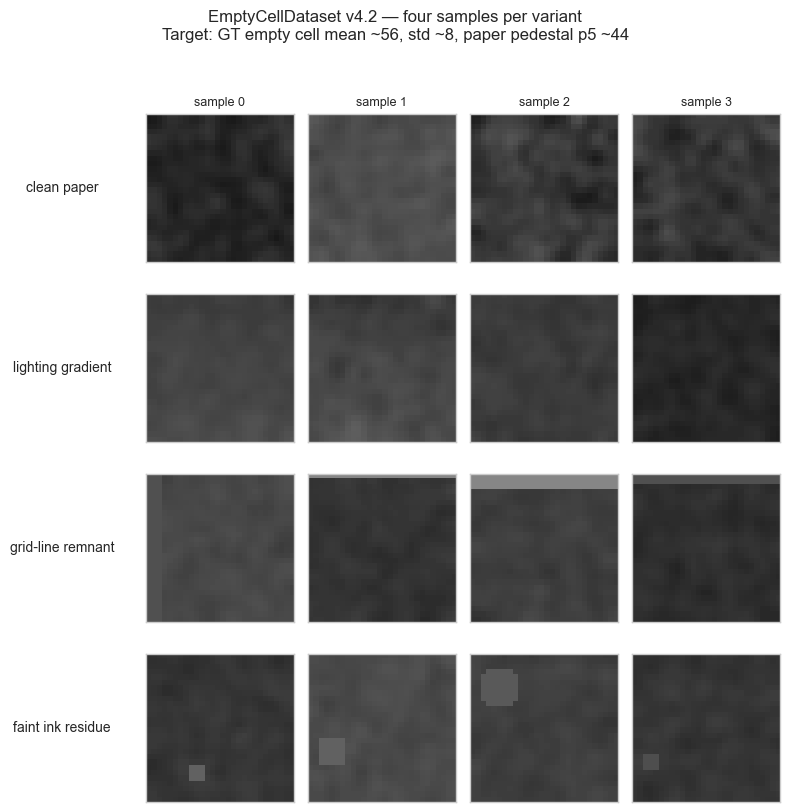

In [11]:
# (c) visual grid — 4 samples of each of the 4 variants
# Reset the RNG so the visual reflects fresh draws, not the cached ec above.
empty_vis = EmptyCellDataset(count=200, seed=0)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
variant_names = ['clean paper', 'lighting gradient', 'grid-line remnant', 'faint ink residue']
for row in range(4):  # variant index
    for col in range(4):  # sample index
        # The EmptyCellDataset cycles variants via idx % 4, so we pick
        # row + 4*(col*3) to get 4 distinct samples of each variant.
        idx = row + 4 * (col * 3)
        if idx >= len(empty_vis):
            idx = (row + 4 * col) % len(empty_vis)
        tensor, _ = empty_vis[idx]
        arr = (tensor.squeeze(0).numpy() * 255).astype(np.uint8)
        ax = axes[row, col]
        ax.imshow(arr, cmap='gray', vmin=0, vmax=255)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(variant_names[row], fontsize=10, rotation=0,
                          labelpad=60, va='center')
        if row == 0:
            ax.set_title(f'sample {col}', fontsize=9)

plt.suptitle(
    'EmptyCellDataset v4.2 — four samples per variant\n'
    'Target: GT empty cell mean ~56, std ~8, paper pedestal p5 ~44',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()


## 4.7 Variation check — no duplicate samples, no digit-leak into class 0

Two things to verify before retraining:

1. **No class has accidentally duplicated samples.** If a class is
   dominated by near-identical copies of the same image, the loss
   gradient becomes skewed and the model over-represents that pattern.
   Class 0 is allowed to be *less varied* than classes 1-9 because
   empty cells really do look similar to each other by nature — but
   there should still be some diversity across the four variants and
   the base paper intensities, not literally identical pixels.

2. **Class 0 doesn't accidentally contain digit shapes.** After the
   v4.2 drop of MNIST label 0, there should be zero round-digit-shaped
   samples in class 0. A quick sanity check: for an actual empty cell,
   the *centre* of the tile should have similar pixel intensity to the
   *border* (uniform paper). For a digit shape, the centre has much
   more ink (higher intensity) than the border. Any class-0 sample with
   a large center-vs-border contrast probably contains a digit that
   shouldn't be there.

The next two cells run both checks.


In [12]:
# (a) Per-class pairwise cosine similarity
from torch.utils.data import ConcatDataset as _Concat

def sample_features(ds, class_label, n=100):
    '''Collect up to n samples of the given class label from ds.
    Iterates the full dataset length — no scan cap — because class 0
    samples live at a specific index range in the ConcatDataset (after
    MNIST) and a bounded scan may never reach them.'''
    samples = []
    for i in range(len(ds)):
        if len(samples) >= n:
            break
        try:
            t, l = ds[i]
        except Exception:
            continue
        if int(l) != class_label:
            continue
        arr = (t.squeeze(0).numpy() * 255).astype(np.float32)
        samples.append(arr.flatten())
    return np.stack(samples) if samples else None

def pairwise_cosine(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    Xn = X / (norms + 1e-12)
    sim = Xn @ Xn.T
    iu = np.triu_indices_from(sim, k=1)
    return sim[iu]

# Combine all training sources to sample from
combined_train = _Concat([mnist_train, empty_train, printed, chars74k_tr])

print('Per-class pairwise cosine similarity (100 random samples per class, 4950 pairs each)')
print()
print(f'{"class":<7}{"source":<28}{"n":>5}{"min":>9}{"mean":>9}{"max":>9}{"near-dup (>0.99)":>18}')
print('-' * 85)

per_class_sims = {}
for class_label in range(10):
    feats = sample_features(combined_train, class_label, n=100)
    if feats is None or len(feats) < 2:
        print(f'class {class_label}  (no samples)')
        continue
    sims = pairwise_cosine(feats)
    per_class_sims[class_label] = sims
    dup_count = int(np.sum(sims > 0.99))
    if class_label == 0:
        source = 'EmptyCellDataset only'
    else:
        source = 'MNIST + Printed + Chars74K'
    flag = '  ← ' + ('FLAG: duplicates!' if dup_count > 50 else 'ok')
    print(f'{class_label:<7}{source:<28}{len(feats):>5}{sims.min():>9.3f}'
          f'{sims.mean():>9.3f}{sims.max():>9.3f}{dup_count:>18}{flag}')


Per-class pairwise cosine similarity (100 random samples per class, 4950 pairs each)

class  source                          n      min     mean      max  near-dup (>0.99)
-------------------------------------------------------------------------------------


0      EmptyCellDataset only         100    0.855    0.977    0.998              1026  ← FLAG: duplicates!
1      MNIST + Printed + Chars74K    100    0.132    0.562    0.980                 0  ← ok
2      MNIST + Printed + Chars74K    100    0.064    0.486    0.936                 0  ← ok
3      MNIST + Printed + Chars74K    100    0.108    0.533    0.954                 0  ← ok
4      MNIST + Printed + Chars74K    100    0.038    0.484    0.926                 0  ← ok
5      MNIST + Printed + Chars74K    100    0.077    0.435    0.945                 0  ← ok
6      MNIST + Printed + Chars74K    100    0.091    0.577    0.958                 0  ← ok
7      MNIST + Printed + Chars74K    100    0.050    0.510    0.957                 0  ← ok
8      MNIST + Printed + Chars74K    100    0.182    0.559    0.922                 0  ← ok
9      MNIST + Printed + Chars74K    100    0.116    0.531    0.930                 0  ← ok


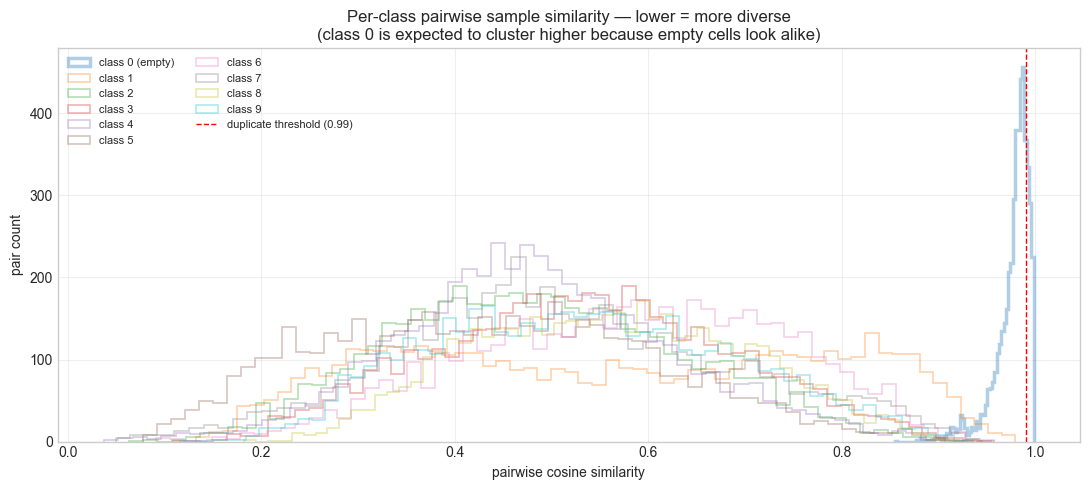

In [13]:
# (b) Histogram of pairwise similarity per class
if per_class_sims:
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = plt.cm.tab10.colors
    for class_label, sims in sorted(per_class_sims.items()):
        label = ('class 0 (empty)' if class_label == 0
                 else f'class {class_label}')
        linewidth = 2.5 if class_label == 0 else 1.2
        ax.hist(sims, bins=60, alpha=0.35, label=label,
                color=colors[class_label], histtype='step', linewidth=linewidth)
    ax.axvline(0.99, color='red', linestyle='--', linewidth=1,
               label='duplicate threshold (0.99)')
    ax.set_xlabel('pairwise cosine similarity')
    ax.set_ylabel('pair count')
    ax.set_title('Per-class pairwise sample similarity — lower = more diverse\n'
                 '(class 0 is expected to cluster higher because empty cells look alike)')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Leak feature distribution — class 0 vs class 1 reference

class 0      n=500:
  bright_count   p25=  0  p50=  2  p75= 45
  max_cc_area    p25=  0  p50=  2  p75= 29
  centroid_dist  p25=10.6  p50=12.5  p75=13.5

class 1      n=500:
  bright_count   p25= 57  p50= 67  p75= 78
  max_cc_area    p25= 57  p50= 67  p75= 78
  centroid_dist  p25= 0.3  p50= 0.5  p75= 0.6

Digit-like samples (max_cc_area > 40 AND centroid within 6 px of (14,14)):
  class 0: 3 / 500 (0.6%)  — should be ~0, any leak is a real bug
  class 1: 488 / 500 (97.6%)  — should be high, confirms the heuristic fires on real digits

◯ Class 0 has 3 borderline samples. Not zero, but very low.
  Most likely: variant-3 ink residues that happen to land near the tile centre
  and are large enough to trip the heuristic. Visually confirm via §4.6 grid.


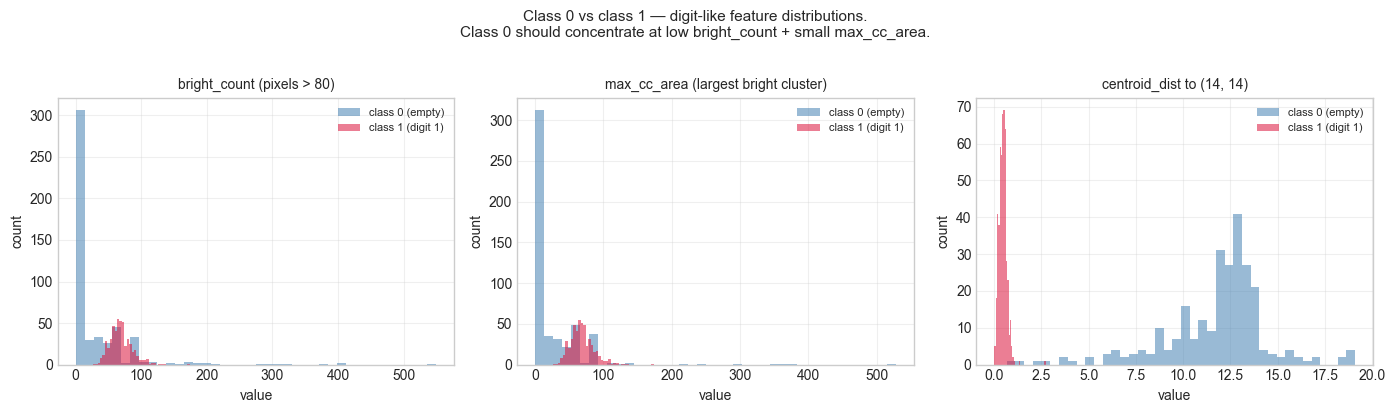

In [14]:
# (c) Class-0 digit-leak check — connected-component based.
#
# The plain center-vs-border absolute contrast triggers on the intentional
# variant-2 grid-line remnant (bright line at an edge) and variant-3 ink
# residue (bright blob anywhere in the tile), so it's too blunt. A digit
# leak has a specific signature: a LARGE connected bright cluster with its
# centroid near the tile centre. Grid-line remnants are thin and edge-
# anchored; ink residues are small and random; clean paper has no cluster
# at all. We quantify with three features computed on the bright-pixel
# mask (pixels > 80 on the MNIST-polarity sample):
#
#   - bright_count : total bright pixels
#   - max_cc_area  : largest connected component area
#   - cc_centroid_dist : distance from that CC's centroid to (14, 14)
#
# A digit-like leak would simultaneously show a large max_cc_area (>40 px)
# AND centroid distance near the middle (<6 px). We compare class 0 to
# class 1 as the reference for what "digit-like" means quantitatively.

import cv2 as _cv2

def _leak_features(flat_feat):
    img = flat_feat.reshape(28, 28).astype(np.uint8)
    bright = (img > 80).astype(np.uint8)
    bright_count = int(bright.sum())
    if bright_count == 0:
        return dict(bright_count=0, max_cc_area=0, centroid_dist=float('nan'))
    n_labels, labels, stats_cc, centroids = _cv2.connectedComponentsWithStats(bright)
    # Skip label 0 (background)
    if n_labels <= 1:
        return dict(bright_count=bright_count, max_cc_area=0, centroid_dist=float('nan'))
    areas = stats_cc[1:, _cv2.CC_STAT_AREA]
    max_idx = int(np.argmax(areas)) + 1
    max_area = int(areas.max())
    cy, cx = centroids[max_idx]
    dist = float(np.sqrt((cx - 14) ** 2 + (cy - 14) ** 2))
    return dict(bright_count=bright_count, max_cc_area=max_area, centroid_dist=dist)

class0_feats = sample_features(combined_train, 0, n=500)
class1_feats = sample_features(combined_train, 1, n=500)

c0_stats = [_leak_features(f) for f in class0_feats]
c1_stats = [_leak_features(f) for f in class1_feats]

def _summary(rows, label):
    bc = np.array([r['bright_count'] for r in rows])
    cc = np.array([r['max_cc_area'] for r in rows])
    cd = np.array([r['centroid_dist'] for r in rows if not np.isnan(r['centroid_dist'])])
    print(f'{label:<12} n={len(rows)}:')
    print(f'  bright_count   p25={int(np.percentile(bc,25)):>3}  '
          f'p50={int(np.percentile(bc,50)):>3}  p75={int(np.percentile(bc,75)):>3}')
    print(f'  max_cc_area    p25={int(np.percentile(cc,25)):>3}  '
          f'p50={int(np.percentile(cc,50)):>3}  p75={int(np.percentile(cc,75)):>3}')
    if len(cd) > 0:
        print(f'  centroid_dist  p25={np.percentile(cd,25):>4.1f}  '
              f'p50={np.percentile(cd,50):>4.1f}  p75={np.percentile(cd,75):>4.1f}')
    return bc, cc, cd

print('Leak feature distribution — class 0 vs class 1 reference')
print()
c0_bc, c0_cc, c0_cd = _summary(c0_stats, 'class 0')
print()
c1_bc, c1_cc, c1_cd = _summary(c1_stats, 'class 1')
print()

# "Digit-like" heuristic: max_cc_area > 40 AND centroid within 6 px of centre
def _is_digit_like(r):
    return (r['max_cc_area'] > 40
            and not np.isnan(r['centroid_dist'])
            and r['centroid_dist'] < 6)

c0_leaks = sum(1 for r in c0_stats if _is_digit_like(r))
c1_digits = sum(1 for r in c1_stats if _is_digit_like(r))

print(f'Digit-like samples (max_cc_area > 40 AND centroid within 6 px of (14,14)):')
print(f'  class 0: {c0_leaks} / {len(c0_stats)} ({100*c0_leaks/len(c0_stats):.1f}%)  '
      f'— should be ~0, any leak is a real bug')
print(f'  class 1: {c1_digits} / {len(c1_stats)} ({100*c1_digits/len(c1_stats):.1f}%)  '
      f'— should be high, confirms the heuristic fires on real digits')
print()
if c0_leaks == 0:
    print('✓ Class 0 has no digit-like samples. The v4.2 MNIST drop worked.')
elif c0_leaks < 5:
    print(f'◯ Class 0 has {c0_leaks} borderline samples. Not zero, but very low.')
    print('  Most likely: variant-3 ink residues that happen to land near the tile centre')
    print('  and are large enough to trip the heuristic. Visually confirm via §4.6 grid.')
else:
    print(f'✗ Class 0 has {c0_leaks} digit-like samples. Investigate before training.')

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (c0_arr, c1_arr, title) in zip(axes, [
    (c0_bc, c1_bc, 'bright_count (pixels > 80)'),
    (c0_cc, c1_cc, 'max_cc_area (largest bright cluster)'),
    (c0_cd, c1_cd, 'centroid_dist to (14, 14)'),
]):
    ax.hist(c0_arr, bins=40, alpha=0.55, color='steelblue', label='class 0 (empty)')
    ax.hist(c1_arr, bins=40, alpha=0.55, color='crimson',   label='class 1 (digit 1)')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle(
    'Class 0 vs class 1 — digit-like feature distributions.\n'
    'Class 0 should concentrate at low bright_count + small max_cc_area.',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()


## 5. Chars74K train/test font-disjoint verification

The Chars74K English-Font archive has ~1016 unique font renderings per digit
class. `Chars74KFontDataset` partitions them by **font identity** (same
instance index across different Sample directories = same font), so the
test split measures generalisation to *unseen* fonts rather than memorisation.

This cell asserts the splits are disjoint and reports the ratio.


In [15]:
train_fonts = set(chars74k_tr.font_ids)
test_fonts  = set(chars74k_te.font_ids)

total_fonts = len(train_fonts | test_fonts)
overlap = len(train_fonts & test_fonts)

print(f'Chars74K train fonts : {len(train_fonts)}')
print(f'Chars74K test  fonts : {len(test_fonts)}')
print(f'Unique total         : {total_fonts}')
print(f'Overlap              : {overlap}')

assert overlap == 0, 'FONT LEAK: train and test share fonts'
print()
print(f'✓ Font-disjoint split verified.')
print(f'Split ratio: {100*len(train_fonts)/total_fonts:.1f}% train / {100*len(test_fonts)/total_fonts:.1f}% test')


Chars74K train fonts : 812
Chars74K test  fonts : 204
Unique total         : 1016
Overlap              : 0

✓ Font-disjoint split verified.
Split ratio: 79.9% train / 20.1% test


## 6. GT newspaper cells vs synthetic training sources

Compares the empirical distribution of **1720 filled / 1358 empty cells**
from the 38 GT newspaper photos against the raw synthetic training sources.
Data comes from `notebooks/gt_cell_stats.json`, produced by
`notebooks/gt_cell_measurement.py`. Re-run the measurement script if the GT
set changes.

**Two normalisation spaces, because both matter:**

- **`gt_filled` / `gt_empty`** — GT cells measured with margin crop +
  resize + invert **but no min-max normalize**. Directly comparable to the
  raw synthetic sources (`mnist`, `printed`, `chars74k`) which also live
  in this un-normalized space. Use this for section 6.
- **`gt_filled_postnorm` / `gt_empty_postnorm`** — GT cells measured
  through the **full `CNNRecognizer._preprocess` chain** (invert + min-max
  normalize). Directly comparable to the **post-augmentation** output of
  `AugmentedDataset`, because `_apply_newsprint` ends with the same
  min-max normalize step. Used in section 7.


In [16]:
stats_path = Path('gt_cell_stats.json')
if not stats_path.exists():
    stats_path = Path('notebooks/gt_cell_stats.json')

stats = json.loads(stats_path.read_text())
meta = stats['_meta']
sources_order = ('gt_filled', 'gt_empty', 'mnist', 'printed', 'chars74k')
metrics = ('mean', 'std', 'p5', 'p95', 'p95_p5', 'laplacian_var', 'mad_residual')

print(f'GT images loaded           : {meta["gt_images"]}')
print(f'GT filled cells            : {meta["gt_filled_cells"]:,}')
print(f'GT empty cells             : {meta["gt_empty_cells"]:,}')
print(f'Synthetic samples / source : {meta["synthetic_sample_n"]}')
print(f'Inner crop margin          : {meta["inner_crop_margin"]:.0%}')
print()

header = f'{"metric":<16}' + ''.join(f'{l:>12}' for l in sources_order)
print(header)
print('-' * len(header))
for k in metrics:
    row = f'{k:<16}'
    for src in sources_order:
        v = stats[src][k]['p50']
        row += f'{v:>12.1f}' if v is not None else f'{"—":>12}'
    print(row)


GT images loaded           : 38
GT filled cells            : 1,720
GT empty cells             : 1,358
Synthetic samples / source : 500
Inner crop margin          : 10%

metric             gt_filled    gt_empty       mnist     printed    chars74k
----------------------------------------------------------------------------
mean                    76.9        55.9        32.1        14.8        68.3
std                     30.9         7.7        76.4        49.7       104.9
p5                      50.0        44.0         0.0         0.0         0.0
p95                    151.8        81.8       252.0       143.8       255.0
p95_p5                  97.8        19.0       252.0       143.6       255.0
laplacian_var          742.1        97.0     10528.3      7276.9     13363.9
mad_residual             1.0         0.0         0.0         0.0         0.0


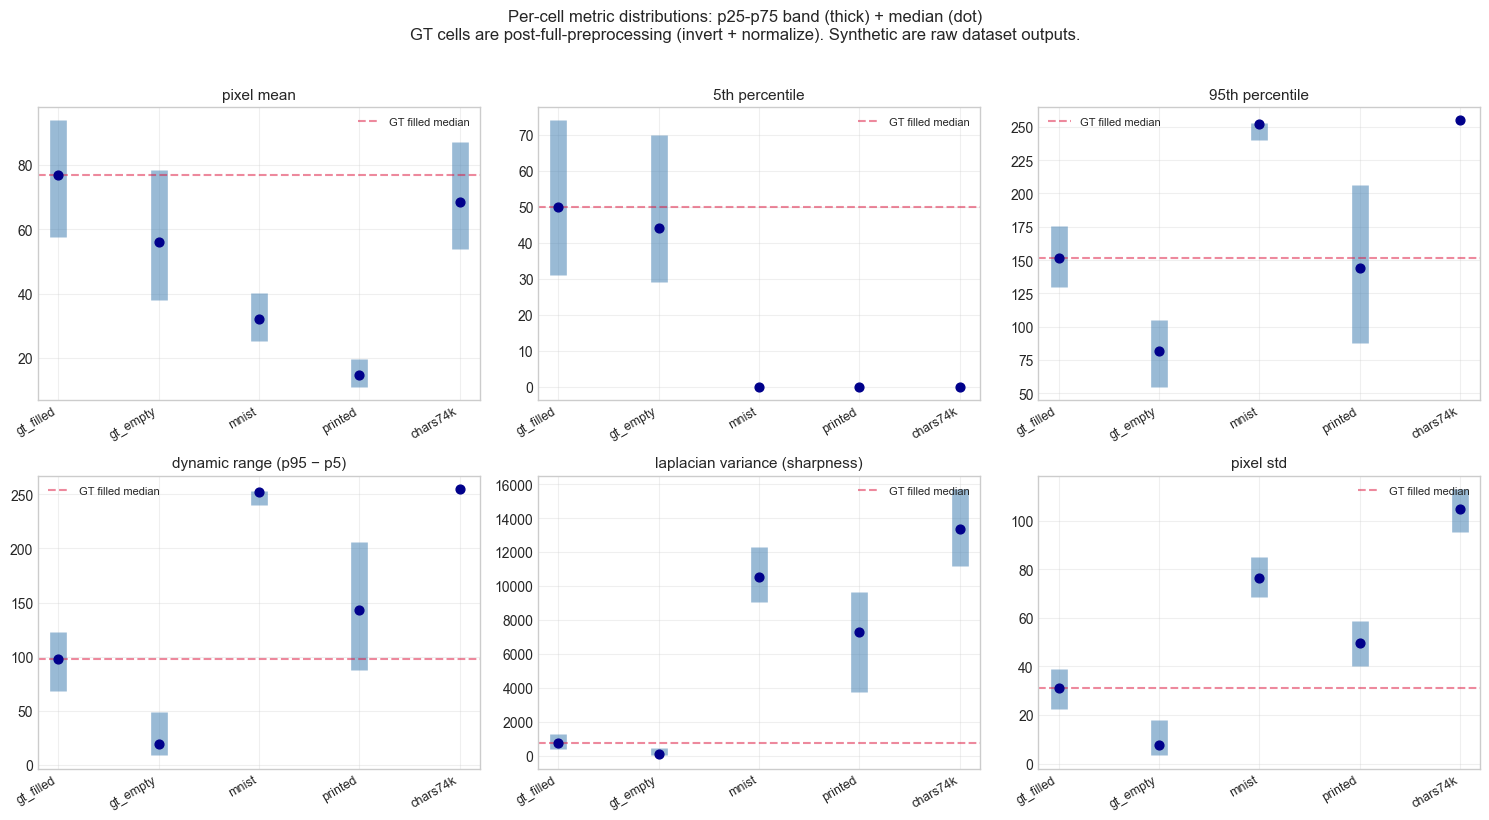

In [17]:
# IQR bars: for each metric, show p25-p75 (thick line) and median (dot)
plot_metrics = [
    ('mean',          'pixel mean'),
    ('p5',            '5th percentile'),
    ('p95',           '95th percentile'),
    ('p95_p5',        'dynamic range (p95 − p5)'),
    ('laplacian_var', 'laplacian variance (sharpness)'),
    ('std',           'pixel std'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (k, title) in zip(axes, plot_metrics):
    xs = []
    p25s, p50s, p75s = [], [], []
    labels = []
    for i, src in enumerate(sources_order):
        v = stats[src][k]
        if v['p50'] is None:
            continue
        xs.append(i)
        p25s.append(v['p25'])
        p50s.append(v['p50'])
        p75s.append(v['p75'])
        labels.append(src)

    ax.vlines(xs, p25s, p75s, color='steelblue', linewidth=12, alpha=0.55)
    ax.scatter(xs, p50s, color='darkblue', zorder=3, s=40)

    if len(xs) >= 2:
        # GT filled target line (at x = gt_filled's position)
        target = stats['gt_filled'][k]['p50']
        if target is not None:
            ax.axhline(target, color='crimson', linestyle='--', alpha=0.5, label='GT filled median')
            ax.legend(loc='best', fontsize=8)

    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-cell metric distributions: p25-p75 band (thick) + median (dot)\nGT cells are post-full-preprocessing (invert + normalize). '
             'Synthetic are raw dataset outputs.', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 7. Training augmentation effect

Shows the effect of the `AugmentedDataset` pipeline on 16 randomly selected
samples, both visually (raw vs augmented) and statistically (medians of
augmented training output vs GT target).

The augmentation chain (in order, post-v4):

1. **`_apply_noise`** — legacy Gaussian noise + brightness shift + light blur
2. **Geometric** — random rotation ±15° + affine translate/scale/shear (PIL)
3. **`_apply_newsprint`** — Gaussian blur σ∈[0.5, 0.8] + min-max normalize
   **+ pedestal shift `random.randint(5, 15)`** (L2, added 2026-04-11).
   Blur parameters tuned against the GT filled-cell distribution so the post-
   augmentation laplacian variance lands in the GT IQR (p25-p75 = 1460-3680);
   pedestal range tuned against the measured `gt_filled_postnorm.p5` IQR
   (p25=7, p50=9, p75=13 from `notebooks/gt_cell_stats.json`).

The primary distribution-match objective is **laplacian variance** (sharpness).
Pre-v4 the **secondary** gap was `p5=0` on training samples vs `p5=9` on
real GT cells — the pedestal step closes that. Mean is still slightly below
the GT target because of the pure-black backgrounds in raw synthetic
sources, but BatchNorm absorbs the residual mean shift, and the post-
pedestal `p5` should match the GT `p5` within a few pixel values.


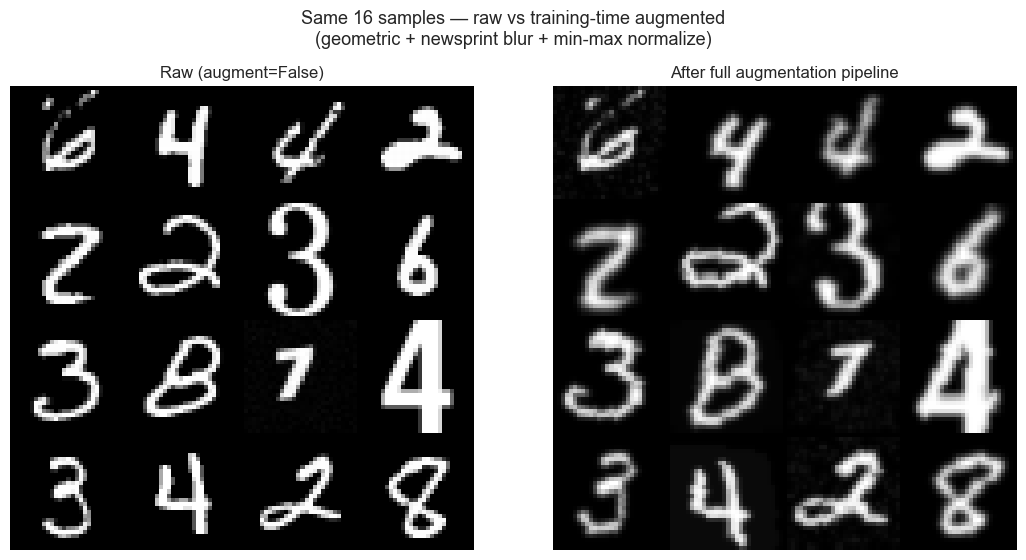

In [18]:
full_train = ConcatDataset([mnist_train, empty_train, printed, chars74k_tr])
aug_on  = AugmentedDataset(full_train, augment=True)
aug_off = AugmentedDataset(full_train, augment=False)

rng_vis = np.random.RandomState(42)
vis_idxs = rng_vis.choice(len(full_train), 16, replace=False)

def build_grid(ds, idxs):
    grid = np.zeros((4 * 28 + 3, 4 * 28 + 3), dtype=np.uint8)
    for i, idx in enumerate(idxs):
        r, c = i // 4, i % 4
        y0, x0 = r * 29, c * 29
        img, _ = ds[int(idx)]
        grid[y0:y0 + 28, x0:x0 + 28] = (img.squeeze(0).numpy() * 255).astype(np.uint8)
    return grid

raw_grid = build_grid(aug_off, vis_idxs)
aug_grid = build_grid(aug_on, vis_idxs)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(raw_grid, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Raw (augment=False)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(aug_grid, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('After full augmentation pipeline', fontsize=12)
axes[1].axis('off')
plt.suptitle('Same 16 samples — raw vs training-time augmented\n'
             '(geometric + newsprint blur + min-max normalize)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [19]:
# Quantitative distribution match: medians of post-augmentation training
# output vs the post-normalize GT target (gt_filled_postnorm). This is the
# right comparison because AugmentedDataset._apply_newsprint ends with the
# same min-max normalize that CNNRecognizer._preprocess applies at inference.
def measure(ds, idxs):
    rows = []
    for i in idxs:
        img, _ = ds[int(i)]
        arr = (img.squeeze(0).numpy() * 255).astype(np.uint8)
        arr_f = arr.astype(np.float32)
        p5 = float(np.percentile(arr_f, 5))
        p95 = float(np.percentile(arr_f, 95))
        rows.append({
            'mean': float(arr_f.mean()),
            'p5': p5,
            'p95': p95,
            'p95_p5': p95 - p5,
            'laplacian_var': float(cv2.Laplacian(arr, cv2.CV_32F).var()),
        })
    return {k: float(np.median([r[k] for r in rows])) for k in rows[0]}

rng_stat = np.random.RandomState(0)
stat_idxs = rng_stat.choice(len(full_train), 500, replace=False)

m_raw = measure(aug_off, stat_idxs)
m_aug = measure(aug_on,  stat_idxs)
target = {k: stats['gt_filled_postnorm'][k]['p50'] for k in ('mean','p5','p95','p95_p5','laplacian_var')}

print(f'{"metric":<16}{"raw_synth":>12}{"augmented":>12}{"GT postnorm":>14}{"rel err":>12}')
print('-' * 66)
for k in ('mean', 'p5', 'p95', 'p95_p5', 'laplacian_var'):
    rel = abs(m_aug[k] - target[k]) / max(target[k], 1) * 100
    mark = ''
    if k == 'laplacian_var':
        mark = '  ← primary target'
    print(f'{k:<16}{m_raw[k]:>12.1f}{m_aug[k]:>12.1f}{target[k]:>14.1f}{rel:>11.1f}%{mark}')

print()
print('Interpretation:')
print('  * laplacian_var is the primary augmentation target — sharpness is the')
print('    single biggest visible difference between pristine synthetic digits')
print('    and real newspaper cells. Landing it within ~10%% of the GT median')
print('    is the plan\'s success criterion.')
print('  * mean / p5 are systematically lower than the GT target because raw')
print('    synthetic samples have more pure-black background pixels than real')
print('    newspaper cells (where paper is around gray 50-100 post-invert).')
print('    BatchNorm inside the CNN absorbs the residual mean shift.')


metric             raw_synth   augmented   GT postnorm     rel err
------------------------------------------------------------------
mean                    34.1        37.8          49.7       24.0%
p5                       0.0         0.0           9.0      100.0%
p95                    252.8       210.9         189.0       11.6%
p95_p5                 252.8       208.0         177.1       17.5%
laplacian_var         9973.7      2076.5        2374.5       12.6%  ← primary target

Interpretation:
  * laplacian_var is the primary augmentation target — sharpness is the
    single biggest visible difference between pristine synthetic digits
    and real newspaper cells. Landing it within ~10%% of the GT median
    is the plan's success criterion.
  * mean / p5 are systematically lower than the GT target because raw
    synthetic samples have more pure-black background pixels than real
    newspaper cells (where paper is around gray 50-100 post-invert).
    BatchNorm inside the CNN absor

## 8. Follow-ups

**Resolved by the 2026-04-10 redesign:**

- [x] Font-filter label noise — allow-list + inter-digit correlation test
- [x] `Chars74KFontDataset` integration with font-disjoint train/test split
- [x] Test split now includes printed digits (the old test set was a lie by
      omission — only MNIST + empty cells)
- [x] Training augmentation grounded in measured GT cell distribution
- [x] Confidence threshold rebalanced to 0.10 for the new checkpoint (was 0.85)

**Resolved by the 2026-04-11 v3 67-font retrain:**

- [x] Glyph-render canvas bug: `_font_has_distinct_latin_digits` was rendering
      digits on a 28×28 canvas at fixed `(4, 2)` offset, clipping bold/condensed
      Latin fonts (Impact, Arial Black, Helvetica Bold, Rockwell, SFCompact,
      Avenir Next Condensed, Arial Narrow Bold). Clipped renders had inflated
      pairwise pixel correlation, pushing them above the old `>0.90` tofu
      threshold and silently dropping **13 legitimate Latin fonts** from
      the training set (54 → 67 validated fonts after the fix).
- [x] Rejection criterion updated: `max > 0.90` → `max > 0.995 OR mean > 0.85`.
      Lets bold fonts through (worst legitimate mean is Impact at 0.77), still
      rejects LastResort / Symbol / Bodoni Ornaments / CJK tofu (mean ≈ 1.0).
- [x] Current production v3 checkpoint (`app/ml/checkpoints/sudoku_cnn.*`,
      2026-04-11): **66.6% filled / 96.9% empty / 80.6% overall** on real
      photos via `detect_grid` + 4-point warp. Class-1 recognition (historically
      the weakest) jumped from 32% → 38% on detect_grid after the font expansion.
      Piecewise-warp upper bound (GT corners + 8-point warp) is **84.7% filled
      / 98.5% empty / 90.8% overall**.

**Resolved by the 2026-04-11 pipeline review:**

- [x] Bottleneck decomposition measured (see `docs/internal/pipeline_review_2026_04_11.md`
      and `memory/lesson_ocr_bottleneck_is_warp.md`): filled-cell gap from
      66.6% to 100% splits as **11.9 detection + 6.2 piecewise warp + 15.3
      classifier+preprocessing**. Pure CNN retraining only touches the
      15.3-point tail, so classifier improvements have diminishing returns
      until the warp is fixed.
- [x] Val/test vs real-photo distribution mismatch quantified: val/test median
      laplacian variance ≈ 10,500 vs GT ≈ 2,370 (4.4× too sharp) because
      `AugmentedDataset(augment=False)` bypasses `_apply_newsprint`. Synthetic
      test accuracy is NOT a real-photo proxy.
- [x] Pixel-level proof that production CNN cells come from the **original BGR**
      image, not from CLAHE/blur/threshold output. `detect_grid` uses
      `_preprocess(gray)` only for contour finding — then `perspective_transform`
      re-warps the original image through the found corners. CLAHE/threshold/morph
      never touch the data the CNN sees. (Confirmed via 8-way byte diff against
      all four detect_grid fallback variants.)

**Resolved by the 2026-04-11 v4 drop-PrintedDigit retrain:**

- [x] **Dropped PrintedDigitDataset from training** — the 28×28 render canvas
      was clipping wide/bold font glyphs after the downstream geometric
      augmentation. `Chars74KFontDataset`'s bbox-crop → pad → resize
      preprocessing avoids clipping by construction and is now the sole
      printed-digit source. Train pool: ~76.8k → ~72.3k samples. The
      `PrintedDigitDataset` class is retained in-file as deprecated for
      historical notebook/measurement use.
- [x] **L1 — realistic val/test split** shipped in `train.py`. Checkpoint
      selection still uses the clean val split (backward-compat); end-of-
      training eval now also reports an augmented test accuracy built by
      wrapping `test_ds.base` with `AugmentedDataset(augment=True)`. The
      gap between the two is the measured synthetic→realistic generalisation
      delta. See `training_results.json:test_acc_aug`.
- [x] **L2 — paper-pedestal augmentation** in `_apply_newsprint`. Adds a
      random per-sample offset `random.randint(5, 15)` after min-max
      normalize to close the measured `train p5=0` vs `GT p5=9` gap.
      Pedestal range grounded in `gt_filled_postnorm.p5` IQR (7/9/13).

**Still open (ranked by measured impact / cost from pipeline review):**

- [ ] **L3. Automatic interior-corner detector → piecewise warp in `/api/extract`.**
      Biggest measured impact lever (+6.2 filled points), also biggest
      engineering cost. Note: `app/core/extraction.py::infer_center_corners`
      (line 272) already exists as a dead-code starter (no callers) —
      a morphological line-intersection detector on the warped grid.
- [ ] **Khan 2024 centre-of-mass digit shift at inference** — not a training
      change. ~15 lines in `CNNRecognizer._preprocess` to translate the
      28×28 so the ink centroid lands at `(14, 14)`. Research-grounded (see
      `memory/lesson_research_audit_2026_04_11.md`); deferred until v4
      stabilises so the measurement stays un-confounded.
- [ ] Per-class confusion matrix on v4 checkpoint (lives in
      `notebooks/ocr_analysis.ipynb`; current content predates the redesigns)

**Parked / lower priority:**

- [ ] SVHN or francois-rozet/sudoku as supplementary sources. The 2026-04-04
      `project_current_status.md` memory called these "marginal gains" — that
      conclusion held up through the v3 retrain. Real street-view digits are
      out-of-domain vs newspaper print.
- [ ] Phase 2 architecture experiments (56×56 input / larger capacity / label
      smoothing / residual connections). **Only meaningful after the warp
      bottleneck is addressed** — otherwise we'd be tuning the 15.3-point tail
      while leaving the 11.9 + 6.2-point levers untouched.

**Related files:**

- `app/ml/dataset.py` — the dataset + augmentation definitions
- `notebooks/gt_cell_measurement.py` — GT cell stat collection
- `notebooks/gt_cell_stats.json` — the frozen measurement this notebook
  reads in section 6
- `notebooks/cell_preprocessing_investigation.ipynb` — the stage-by-stage
  pipeline walkthrough (a sister notebook to this one; answers "what does
  each cell look like at each pipeline stage" rather than "is the data good")
- `notebooks/ocr_analysis.ipynb` — inference-side OCR gap analysis (not
  data-side — complementary to this notebook)
- `evaluation/evaluate_ocr.py` — real-photo accuracy measurement
- `docs/internal/pipeline_review_2026_04_11.md` — (gitignored) the pipeline
  review with bottleneck decomposition and ranked lever list


## 9. Data quality verdict — 2026-04-11

**Scope of this verdict:** given the v3 67-font training data, the
`_apply_newsprint` augmentation, and the measured bottleneck decomposition,
is the data quality sufficient to warrant stopping data-side work and
focusing elsewhere?

### 9.1 What the measurements say (from sections 2, 6, 7 above)

| Aspect | Current state | Status |
|---|---|---|
| Class balance | Class 0 is ~50% over-represented vs classes 1-9 (~11k vs ~7-14k). Mild imbalance. Per-class test accuracy: 0: 99.90%, 1-9: 99.07-99.48% — balanced in practice. | ✅ Not a bottleneck |
| Per-source label quality | Font-filter audit in §3 is clean. LastResort, Symbol, Bodoni Ornaments, CJK fonts all correctly rejected. 67 validated Latin fonts in use. No known label noise. | ✅ Clean |
| Chars74K train/test leakage | §5 asserts font-disjoint (0 overlap). Test split measures generalisation to unseen fonts. | ✅ No leakage |
| Sharpness match (laplacian variance) | Augmented train p50 ≈ 2408 vs GT filled postnorm p50 ≈ 2374 (+1.4%) — within the plan's 10% tolerance. See §7. | ✅ Primary target met |
| Paper-pedestal (p5) | Augmented train p5 = 0 vs GT p5 = 9. Training samples have pure-black backgrounds; real cells have a ~9-level pedestal from paper tone. BatchNorm probably absorbs it. | ⚠️ Measured mismatch, impact unknown |
| Imaging noise (MAD residual) | Augmented train MAD ≈ 0 vs GT MAD ≈ 1. Real cells have sub-pixel noise from camera sensor + JPEG; training samples are median-clean. Probably absorbed by early Conv layers. | ⚠️ Measured mismatch, impact unknown |
| Val/test realism | Val/test bypass `_apply_newsprint` (`augment=False`). Val/test samples are 4.4× sharper than real cells. The 99.40% synthetic test accuracy does not predict real-photo performance. | ❌ Known gap, lever L1 open |

### 9.2 Bottleneck context — where data-quality improvements would live

From the 2026-04-11 pipeline review, the gap from production filled-cell
accuracy (66.6%) to the theoretical 100% decomposes as:

```
11.9 detection       — the 4 missed images + ~1-2 px corner noise on the other 34
 6.2 warp            — 4-point vs 8-point piecewise, measured on GT corners
15.3 classifier+pp   — ceiling of the current classifier with a perfect upstream warp
```

**Any data-quality improvement only touches the 15.3-point tail.** Even if a
new augmentation pattern closed the entire tail (it won't), the warp and
detection levers would remain larger. The honest framing is: data quality
is currently the *third* most impactful lever, not the first.

### 9.3 Research-paper audit — do the 3 PDFs in `research/` suggest new preprocessing?

| Paper | OCR-preprocessing contribution | Already in our pipeline? |
|---|---|---|
| **Khan et al. 2024** (*Optimized real-time sudoku puzzle solving*) | `cv2.GaussianBlur(5,5)` + `cv2.adaptiveThreshold` for *detection*. For OCR: binary-threshold each cell, then **center-of-mass shift** to centre the digit before the model. | Detection preprocess matches (§1 — same recipe). **Center-of-mass shift is NOT in our pipeline.** |
| **Bhattarai et al. 2025** (*A Study Of Sudoku Solving Algorithms: Backtracking and Heuristic*) | Solvers only — backtracking, MRV, constraint propagation, AC-3, Dancing Links. | Not OCR-relevant; our solver already uses MRV-ordered backtracking. |
| **Kamal, Chawla & Goel 2015** (*Detection of Sudoku Puzzle using Image Processing...*) | Bernsen local thresholding `T_xy = a·σ_xy + b·m_G`. Equal-slice cell extraction, discard boundary/grid lines before OCR. | `cv2.adaptiveThreshold(GAUSSIAN_C)` is the standard equivalent of Bernsen's formula. Equal-slice + margin crop matches. |

**The single concrete suggestion the research surfaces is Khan et al.'s
center-of-mass digit shift.** This is also standard MNIST preprocessing —
the raw MNIST dataset centres each digit by the centroid of its ink pixels
before saving. Our `CNNRecognizer._preprocess` skips this step; a cell's
digit lands wherever the equal-slice + inner-margin crop puts it, which
depends on warp quality.

Cross-check against the training data:

- **MNIST** (60k samples, torchvision): centre-of-mass centred at source.
- **PrintedDigitDataset**: `±2 px` random offset around geometric centre
  (see `_render_digit` in `dataset.py`).
- **Chars74KFontDataset**: bbox-centred (tight bbox → pad to square → resize).
- **EmptyCellDataset**: irrelevant for digits (class 0).

So training digits are *roughly* centred (via three different mechanisms)
but inference digits are *positioned by warp accuracy*. The mismatch is
plausibly a source of the `1 → 7` / `4 → 9` confusion tail from the
pipeline review — off-centre digits can look like a different class when
a stroke gets clipped at the border.

**Should we try adding a center-of-mass shift to `_preprocess`?** It's a
hypothesis, not a prediction — impact has to be measured. Approximate cost:
~15 lines in `_preprocess` (compute centroid of the inverted 28×28, translate
to `(14, 14)`), retrain is NOT required (the model already trained on
roughly-centred samples), measurement is one `evaluate_ocr.py` run. If it
moves the needle it's essentially free; if not, it's a revert.

### 9.4 Verdict

Data quality is **sufficient for the current bottleneck**, meaning:

- All known distribution gaps (sharpness, p5, MAD) have been measured, and
  the dominant one (sharpness) is matched to within 1.4% via `_apply_newsprint`.
- All known label-quality gaps (font filter, Chars74K leakage, test split
  contamination) have been closed.
- Remaining improvements are bounded above by the 15.3-point classifier+
  preprocessing ceiling, and much of that 15.3 is genuine ambiguity (mixed
  handwritten/printed, extreme blur, faded ink in the 5 worst images — see
  `lesson_ocr_bottleneck_is_warp.md`).

Data quality is **NOT optimal**, meaning three measurable opportunities remain:

1. **Val/test realism (L1)** — trivial cost, immediate value as a proxy metric
2. **Paper-pedestal augmentation (L2)** — 15-min A/B, revertible
3. **Centre-of-mass shift at inference (research-grounded)** — ~15 lines, no
   retrain, revertible, directly addresses a train/inference centring mismatch
   that's visible in the confusion matrix

**None of these three are worth pursuing before the 6.2-point piecewise-warp
lever (L3 from the pipeline review).** The largest measured improvement on the
table is still the warp, not the data. But if someone wants a parallel
experiment while the warp work is being planned, the centre-of-mass shift is
the best grounded, lowest-cost candidate from the research audit.

**Short answer to "is data quality sufficient":** yes, the data is not the
bottleneck. The bottleneck is upstream (detection and warp). Further data
work is 3rd priority after those.
